In [1]:
# CELL 1 — IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from scipy.stats import skew, kurtosis, zscore
from statsmodels.stats.weightstats import ztest

print('All imports successful')

All imports successful


In [3]:
# CELL 2 — LOAD DATASET
df = pd.read_csv('/content/your_dataset_5000.csv')

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Dataset Shape:', df.shape)
print('\nLabel Distribution:')
print(df['label'].value_counts())
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (460, 2)

Label Distribution:
label
1    230
0    230
Name: count, dtype: int64

First 5 rows:


,text,label
0,Exercise plays a crucial role in supporting me...,1
1,Renewable energy helps fight climate change by...,1
2,"A futuristic smart city is a vibrant, intercon...",1
3,Healthy eating habits are especially important...,1
4,Machine learning is transforming healthcare by...,1


In [5]:
# CELL 3 — TEXT CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print('Text cleaning done')

Text cleaning done


In [6]:
# CELL 4 — FEATURE ENGINEERING (14 FEATURES)

# Feature 1: Total character count
df['char_count'] = df['text'].apply(len)

# Feature 2: Total word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Feature 3: Average word length
df['avg_word_length'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

# Feature 4: Unique word ratio (vocabulary diversity)
df['unique_word_ratio'] = df['clean_text'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0
)

# Feature 5: Sentence count
df['sentence_count'] = df['text'].apply(
    lambda x: max(1, len(re.split(r'[.!?]+', x.strip())))
)

# Feature 6: Average sentence length (words per sentence)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count']

# Feature 7: Stopword ratio
df['stopword_ratio'] = df['clean_text'].apply(
    lambda x: len([w for w in x.split() if w in STOP_WORDS]) / len(x.split())
    if x.split() else 0
)

# Feature 8: Capital letter ratio
df['capital_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)

# Feature 9: Punctuation count
df['punctuation_count'] = df['text'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)

# Feature 10: Exclamation mark count
df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))

# Feature 11: Question mark count
df['question_count'] = df['text'].apply(lambda x: x.count('?'))

# Feature 12: Digit count
df['digit_count'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x))

# Feature 13: Long word count (words > 6 chars)
df['long_word_count'] = df['clean_text'].apply(
    lambda x: sum(1 for w in x.split() if len(w) > 6)
)

# Feature 14: Long word ratio
df['long_word_ratio'] = df['clean_text'].apply(
    lambda x: sum(1 for w in x.split() if len(w) > 6) / len(x.split())
    if x.split() else 0
)

FEATURES = [
    'char_count', 'word_count', 'avg_word_length', 'unique_word_ratio',
    'sentence_count', 'avg_sentence_length', 'stopword_ratio', 'capital_ratio',
    'punctuation_count', 'exclamation_count', 'question_count',
    'digit_count', 'long_word_count', 'long_word_ratio'
]

print(f'Feature Engineering Complete — {len(FEATURES)} features created')
print('\nFeature List:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')
print('\nFeature Statistics:')
df[FEATURES].describe().round(4)

Feature Engineering Complete — 14 features created

Feature List:
   1. char_count
   2. word_count
   3. avg_word_length
   4. unique_word_ratio
   5. sentence_count
   6. avg_sentence_length
   7. stopword_ratio
   8. capital_ratio
   9. punctuation_count
  10. exclamation_count
  11. question_count
  12. digit_count
  13. long_word_count
  14. long_word_ratio

Feature Statistics:


,char_count,word_count,avg_word_length,unique_word_ratio,sentence_count,avg_sentence_length,stopword_ratio,capital_ratio,punctuation_count,exclamation_count,question_count,digit_count,long_word_count,long_word_ratio
count,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000,460.0,460.0000,460.0000,460.0000
mean,105.1630,15.5609,5.7361,0.9727,2.1391,6.5395,0.2932,0.0184,2.0500,0.0065,0.0,0.0130,6.0087,0.3948
std,125.0243,18.0197,1.2707,0.0544,0.7685,2.5427,0.1383,0.0101,3.1505,0.0806,0.0,0.1314,7.4722,0.2022
min,39.0000,5.0000,3.2500,0.6957,2.0000,2.5000,0.0000,0.0058,1.0000,0.0000,0.0,0.0000,0.0000,0.0000
25%,64.0000,11.0000,4.6859,0.9444,2.0000,5.5000,0.1818,0.0103,1.0000,0.0000,0.0,0.0000,3.0000,0.2308
50%,78.0000,13.0000,5.7321,1.0000,2.0000,6.5000,0.2857,0.0155,1.0000,0.0000,0.0,0.0000,4.0000,0.3846
75%,103.2500,14.0000,6.7232,1.0000,2.0000,7.0000,0.4000,0.0236,2.0000,0.0000,0.0,0.0000,7.0000,0.5402
max,869.0000,125.0000,10.1111,1.0000,7.0000,21.0000,0.6429,0.0600,26.0000,1.0000,0.0,2.0000,58.0000,1.0000


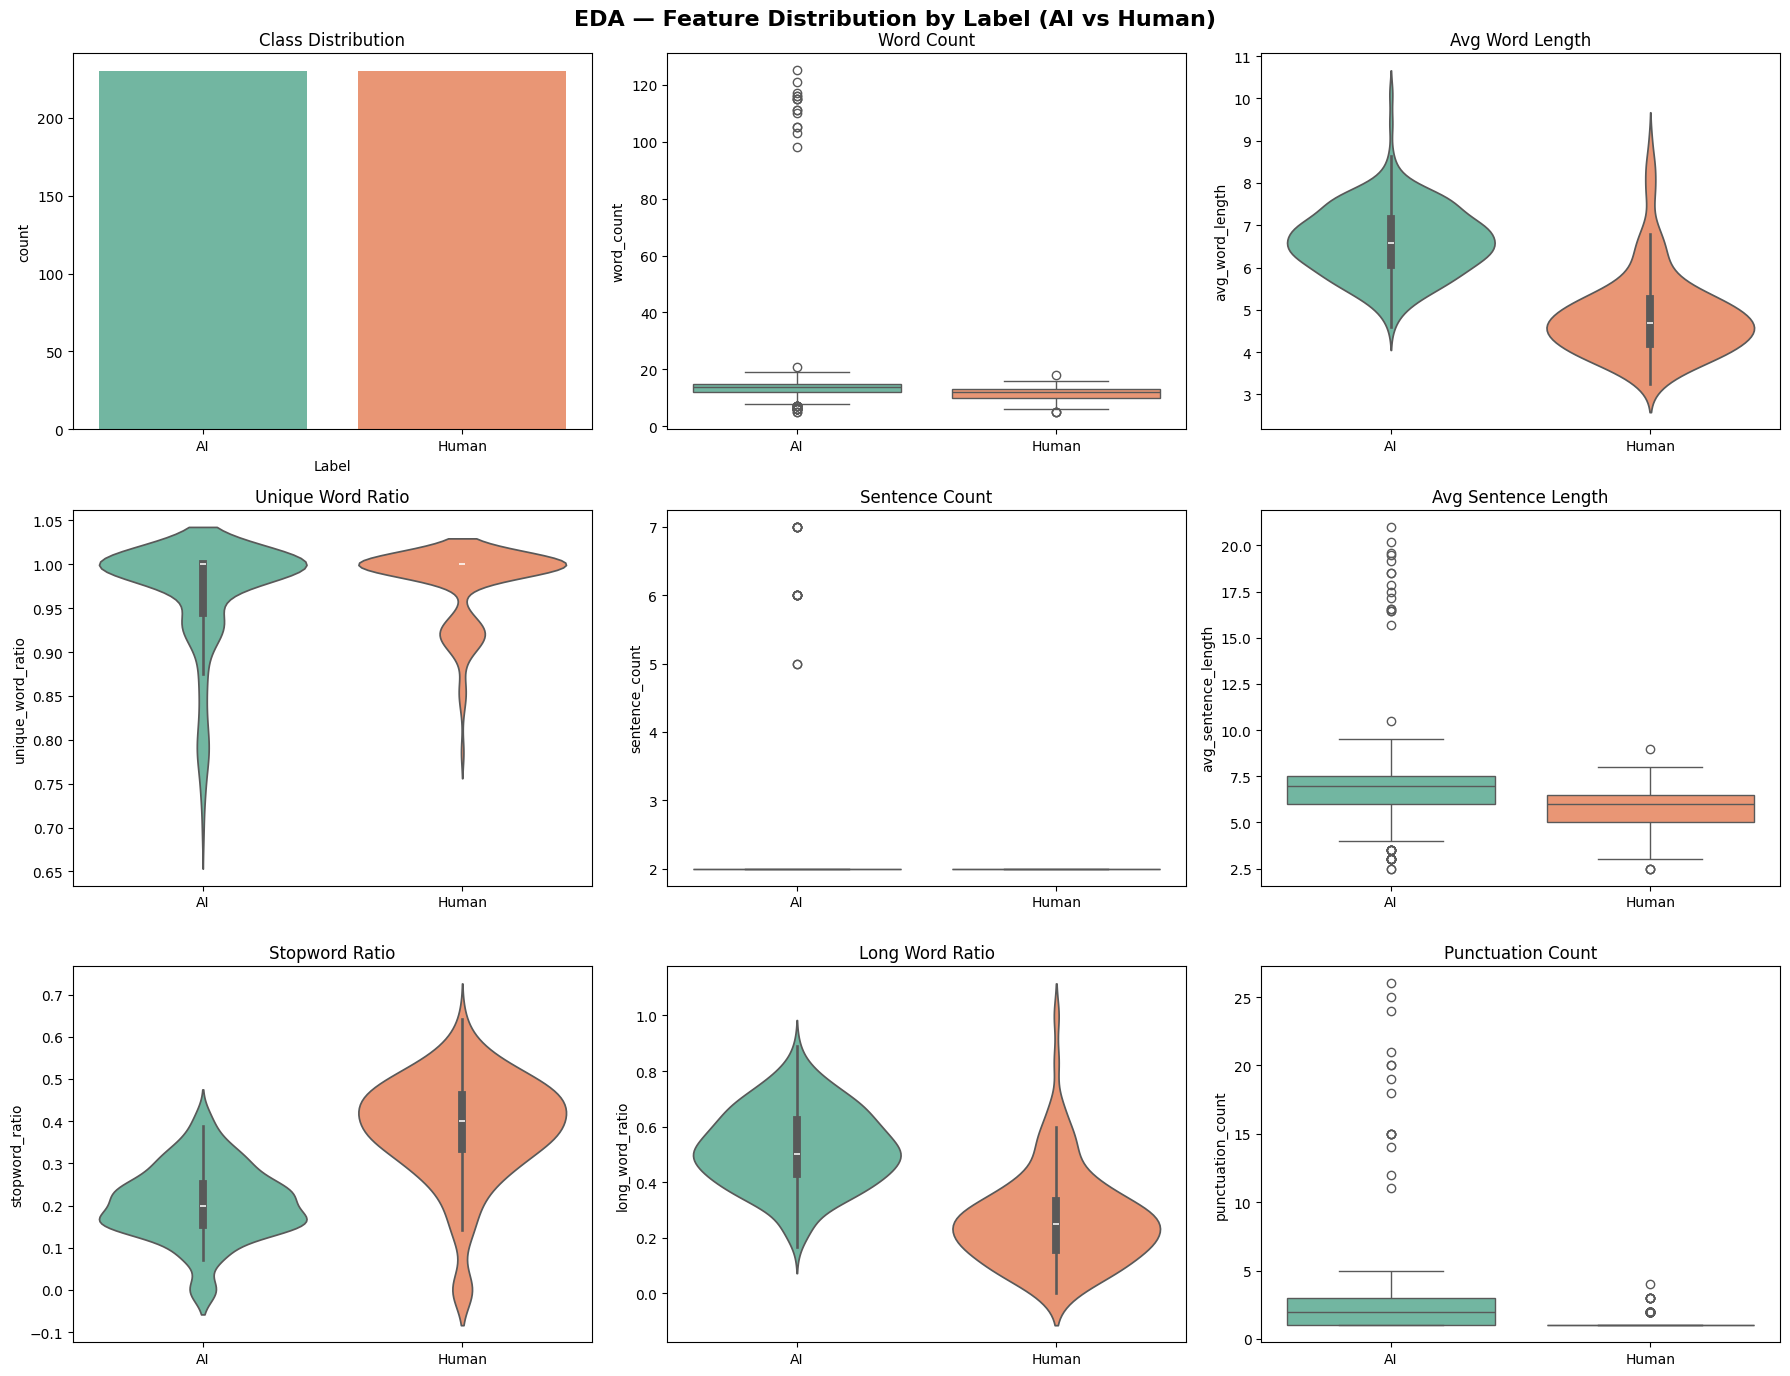

In [7]:
# CELL 5 — EDA: FEATURE DISTRIBUTION BY LABEL
label_map = {0: 'Human', 1: 'AI'}
df['label_name'] = df['label'].map(label_map)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('EDA — Feature Distribution by Label (AI vs Human)', fontsize=16, fontweight='bold')

sns.countplot(x='label_name', data=df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_xlabel('Label')

plot_features = [
    ('word_count', 'box'), ('avg_word_length', 'violin'),
    ('unique_word_ratio', 'violin'), ('sentence_count', 'box'),
    ('avg_sentence_length', 'box'), ('stopword_ratio', 'violin'),
    ('long_word_ratio', 'violin'), ('punctuation_count', 'box')
]
ax_list = [axes[0,1], axes[0,2], axes[1,0], axes[1,1],
           axes[1,2], axes[2,0], axes[2,1], axes[2,2]]

for ax, (feat, plot_type) in zip(ax_list, plot_features):
    if plot_type == 'box':
        sns.boxplot(x='label_name', y=feat, data=df, palette='Set2', ax=ax)
    else:
        sns.violinplot(x='label_name', y=feat, data=df, palette='Set2', ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

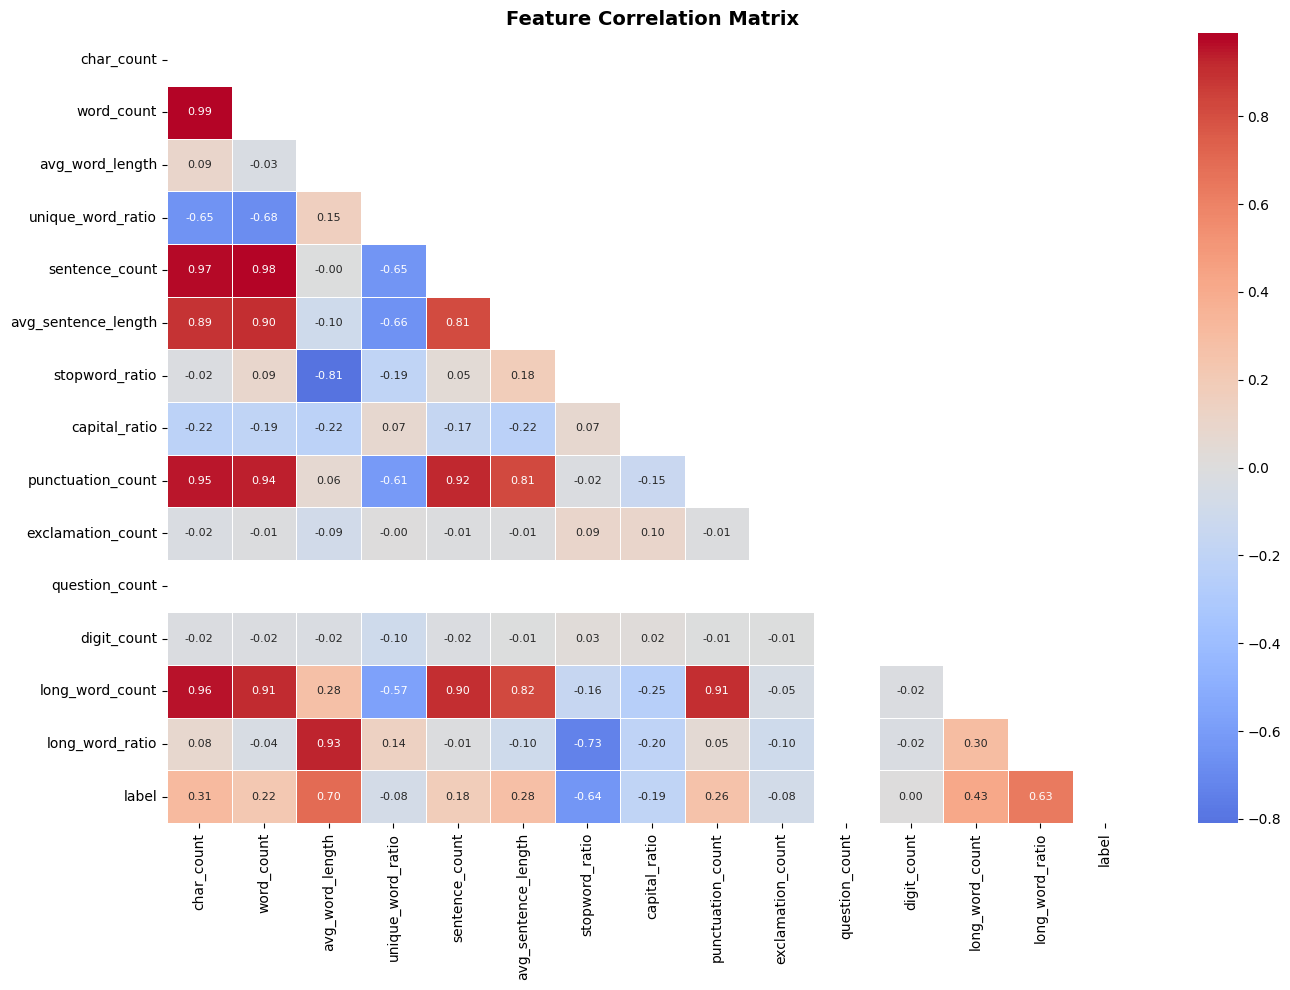


Top Features Correlated with Label:
avg_word_length        0.6998
stopword_ratio        -0.6393
long_word_ratio        0.6349
long_word_count        0.4252
char_count             0.3088
avg_sentence_length    0.2834
punctuation_count      0.2563
word_count             0.2179
capital_ratio         -0.1927
sentence_count         0.1812
exclamation_count     -0.0810
unique_word_ratio     -0.0751
digit_count            0.0000
question_count            NaN
Name: label, dtype: float64


In [8]:
# CELL 6 — FEATURE CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
corr = df[FEATURES + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop Features Correlated with Label:')
label_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)
print(label_corr.round(4))

In [9]:
# CELL 7 — SKEWNESS & KURTOSIS (ALL 14 FEATURES) — SYMMETRY CHECK
print('=' * 65)
print('  STATISTICAL ANALYSIS — SYMMETRY CHECK (ALL 14 FEATURES)')
print('=' * 65)

sym_results = []

for feat in FEATURES:
    data = df[feat]
    sk   = skew(data)
    kurt = kurtosis(data)

    if abs(sk) < 0.5:
        sym_label = 'Approximately Symmetric'
    elif sk > 0.5:
        sym_label = 'Right-Skewed (positive tail)'
    else:
        sym_label = 'Left-Skewed (negative tail)'

    if abs(kurt) < 1:
        kurt_label = 'Mesokurtic (normal-like)'
    elif kurt > 1:
        kurt_label = 'Leptokurtic (heavy tails)'
    else:
        kurt_label = 'Platykurtic (flat tails)'

    sym_results.append({
        'Feature': feat, 'Mean': round(data.mean(), 3),
        'Std': round(data.std(), 3), 'Skewness': round(sk, 4),
        'Kurtosis': round(kurt, 4), 'Symmetry': sym_label
    })

    print(f'\n{feat}')
    print(f'   Mean     : {data.mean():.4f}   |   Std: {data.std():.4f}')
    print(f'   Skewness : {sk:.4f}  ->  {sym_label}')
    print(f'   Kurtosis : {kurt:.4f}  ->  {kurt_label}')

sym_df = pd.DataFrame(sym_results)
print('\n\nSummary Table:')
sym_df[['Feature', 'Skewness', 'Kurtosis', 'Symmetry']]

  STATISTICAL ANALYSIS — SYMMETRY CHECK (ALL 14 FEATURES)

char_count
   Mean     : 105.1630   |   Std: 125.0243
   Skewness : 5.0524  ->  Right-Skewed (positive tail)
   Kurtosis : 24.8383  ->  Leptokurtic (heavy tails)

word_count
   Mean     : 15.5609   |   Std: 18.0197
   Skewness : 5.1029  ->  Right-Skewed (positive tail)
   Kurtosis : 24.9211  ->  Leptokurtic (heavy tails)

avg_word_length
   Mean     : 5.7361   |   Std: 1.2707
   Skewness : 0.1933  ->  Approximately Symmetric
   Kurtosis : -0.6473  ->  Mesokurtic (normal-like)

unique_word_ratio
   Mean     : 0.9727   |   Std: 0.0544
   Skewness : -2.3026  ->  Left-Skewed (negative tail)
   Kurtosis : 5.3473  ->  Leptokurtic (heavy tails)

sentence_count
   Mean     : 2.1391   |   Std: 0.7685
   Skewness : 5.4662  ->  Right-Skewed (positive tail)
   Kurtosis : 28.5412  ->  Leptokurtic (heavy tails)

avg_sentence_length
   Mean     : 6.5395   |   Std: 2.5427
   Skewness : 2.9911  ->  Right-Skewed (positive tail)
   Kurtosis : 12.

,Feature,Skewness,Kurtosis,Symmetry
0,char_count,5.0524,24.8383,Right-Skewed (positive tail)
1,word_count,5.1029,24.9211,Right-Skewed (positive tail)
2,avg_word_length,0.1933,-0.6473,Approximately Symmetric
3,unique_word_ratio,-2.3026,5.3473,Left-Skewed (negative tail)
4,sentence_count,5.4662,28.5412,Right-Skewed (positive tail)
5,avg_sentence_length,2.9911,12.6279,Right-Skewed (positive tail)
6,stopword_ratio,0.0230,-0.6498,Approximately Symmetric
7,capital_ratio,1.3656,1.7114,Right-Skewed (positive tail)
8,punctuation_count,5.2791,29.6325,Right-Skewed (positive tail)
9,exclamation_count,12.2613,148.3399,Right-Skewed (positive tail)


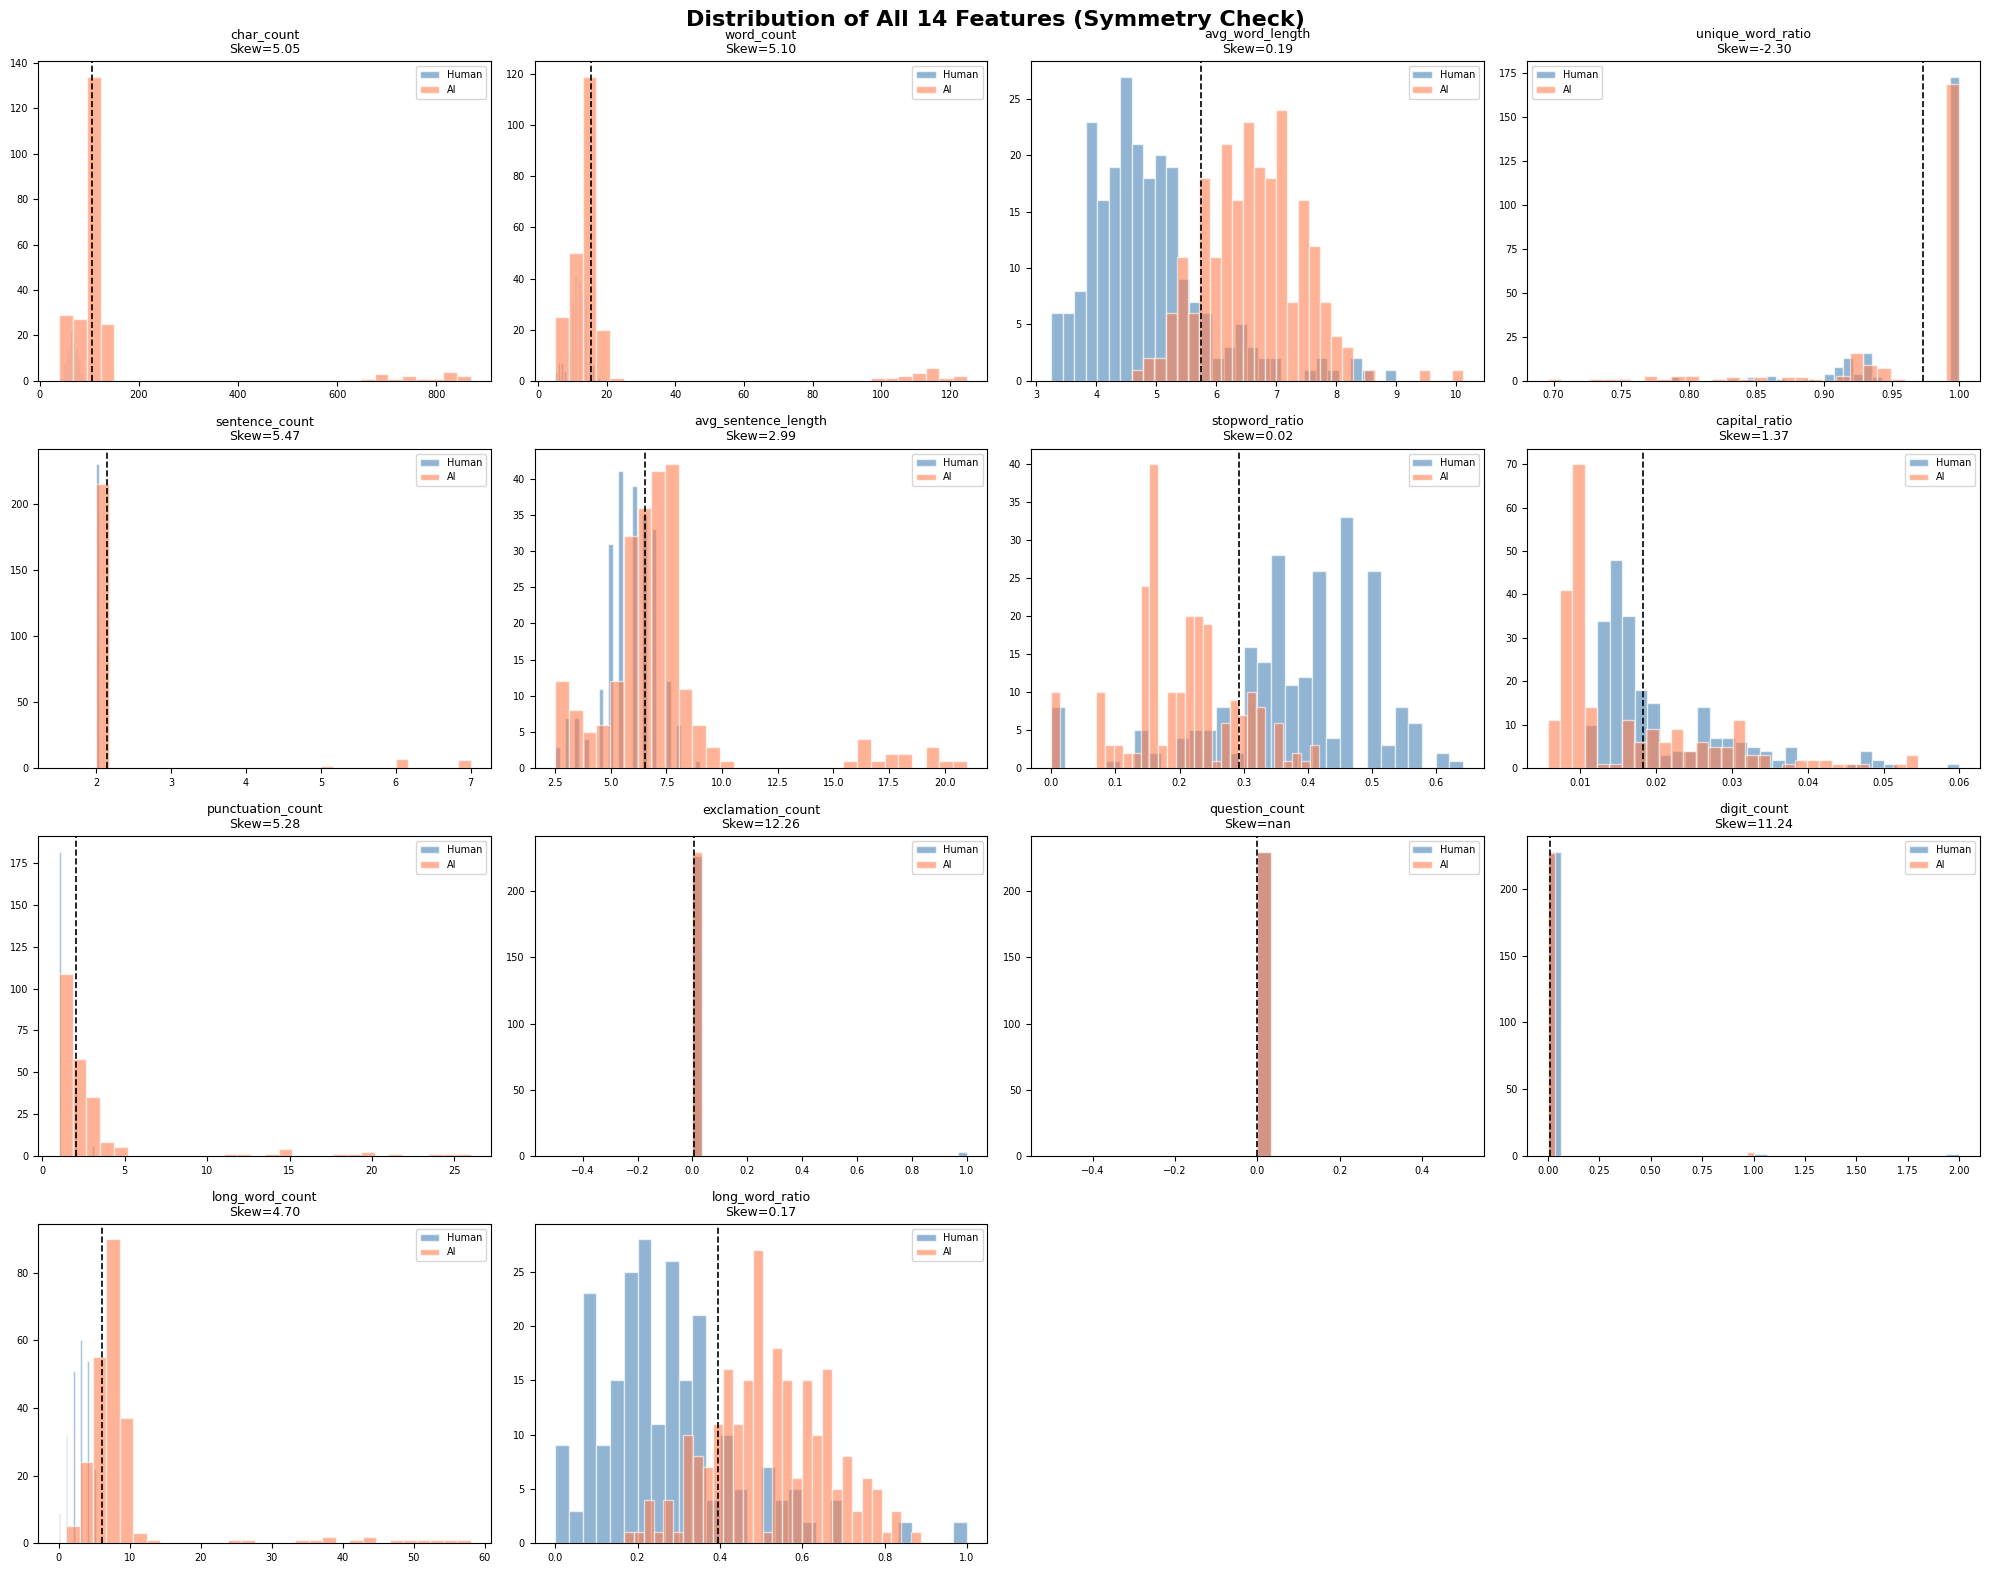

In [10]:
# CELL 8 — SKEWNESS VISUALIZATION (ALL 14 FEATURES)
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Distribution of All 14 Features (Symmetry Check)', fontsize=16, fontweight='bold')

colors_plot = ['steelblue', 'coral']
ax_flat = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = ax_flat[i]
    for label_val, color in zip([0, 1], colors_plot):
        data = df[df['label'] == label_val][feat]
        ax.hist(data, bins=30, alpha=0.6, color=color,
                label=label_map[label_val], edgecolor='white')
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2)
    sk_val = skew(df[feat])
    ax.set_title(f'{feat}\nSkew={sk_val:.2f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(FEATURES), len(ax_flat)):
    ax_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# CELL 9 — Z-SCORE OUTLIER DETECTION
print('=' * 65)
print('  Z-SCORE OUTLIER DETECTION  (|z| > 3 = outlier)')
print('=' * 65)

for feat in FEATURES:
    z_scores = np.abs(zscore(df[feat]))
    outliers = (z_scores > 3).sum()
    pct = outliers / len(df) * 100
    print(f'{feat:30s}: {outliers:4d} outliers ({pct:.2f}%)')

z = np.abs(zscore(df['char_count']))
df_clean = df[z < 3].copy()
print(f'\nDataset after outlier removal: {df_clean.shape[0]} rows')
print(f'Rows removed: {len(df) - len(df_clean)}')

  Z-SCORE OUTLIER DETECTION  (|z| > 3 = outlier)
char_count                    :   15 outliers (3.26%)
word_count                    :   15 outliers (3.26%)
avg_word_length               :    1 outliers (0.22%)
unique_word_ratio             :   16 outliers (3.48%)
sentence_count                :   15 outliers (3.26%)
avg_sentence_length           :   15 outliers (3.26%)
stopword_ratio                :    0 outliers (0.00%)
capital_ratio                 :    8 outliers (1.74%)
punctuation_count             :   14 outliers (3.04%)
exclamation_count             :    3 outliers (0.65%)
question_count                :    0 outliers (0.00%)
digit_count                   :    5 outliers (1.09%)
long_word_count               :   13 outliers (2.83%)
long_word_ratio               :    0 outliers (0.00%)

Dataset after outlier removal: 445 rows
Rows removed: 15


In [12]:
# CELL 10 — TWO-SAMPLE Z-TEST (AI vs HUMAN)
print('=' * 65)
print('  TWO-SAMPLE Z-TEST: AI vs Human (Key Features)')
print('=' * 65)

test_features = ['char_count', 'word_count', 'unique_word_ratio',
                 'avg_sentence_length', 'long_word_ratio', 'stopword_ratio']

for feat in test_features:
    ai_vals    = df_clean[df_clean['label'] == 1][feat]
    human_vals = df_clean[df_clean['label'] == 0][feat]
    z_stat, p_value = ztest(ai_vals, human_vals, alternative='two-sided')
    result = 'Significant (p < 0.05)' if p_value < 0.05 else 'Not Significant (p >= 0.05)'
    print(f'\n{feat}')
    print(f'   AI Mean    : {ai_vals.mean():.4f}')
    print(f'   Human Mean : {human_vals.mean():.4f}')
    print(f'   Z-Statistic: {z_stat:.4f}  |  P-Value: {p_value:.6f}')
    print(f'   Result     : {result}')

  TWO-SAMPLE Z-TEST: AI vs Human (Key Features)

char_count
   AI Mean    : 100.0372
   Human Mean : 66.5913
   Z-Statistic: 20.9176  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)

word_count
   AI Mean    : 13.0140
   Human Mean : 11.6391
   Z-Statistic: 5.3036  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)

unique_word_ratio
   AI Mean    : 0.9820
   Human Mean : 0.9768
   Z-Statistic: 1.3348  |  P-Value: 0.181949
   Result     : Not Significant (p >= 0.05)

avg_sentence_length
   AI Mean    : 6.5070
   Human Mean : 5.8196
   Z-Statistic: 5.3036  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)

long_word_ratio
   AI Mean    : 0.5328
   Human Mean : 0.2666
   Z-Statistic: 17.9933  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)

stopword_ratio
   AI Mean    : 0.1961
   Human Mean : 0.3815
   Z-Statistic: -18.5514  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)


In [13]:
# CELL 11 — MODEL SET 1: 14 NUMERICAL FEATURES
X_num = df_clean[FEATURES].values
y     = df_clean['label'].values

X_train_n, X_test_n, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_n_sc = scaler.fit_transform(X_train_n)
X_test_n_sc  = scaler.transform(X_test_n)

num_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

num_results = {}

print('=' * 65)
print('  MODEL SET 1 — TRAINED ON 14 NUMERICAL FEATURES')
print('=' * 65)

for name, model in num_models.items():
    model.fit(X_train_n_sc, y_train)
    pred = model.predict(X_test_n_sc)
    acc  = accuracy_score(y_test, pred)
    cv   = cross_val_score(model, scaler.fit_transform(X_num), y, cv=5, scoring='accuracy')
    num_results[name] = {'accuracy': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std(), 'model': model}
    print(f'\n--- {name} ---')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  CV (5-fold)   : {cv.mean():.4f} +/- {cv.std():.4f}')
    print(classification_report(y_test, pred, target_names=['Human', 'AI']))

  MODEL SET 1 — TRAINED ON 14 NUMERICAL FEATURES

--- Logistic Regression ---
  Test Accuracy : 0.8315
  CV (5-fold)   : 0.9124 +/- 0.1305
              precision    recall  f1-score   support

       Human       0.80      0.89      0.85        46
          AI       0.87      0.77      0.81        43

    accuracy                           0.83        89
   macro avg       0.84      0.83      0.83        89
weighted avg       0.84      0.83      0.83        89


--- Random Forest ---
  Test Accuracy : 0.8427
  CV (5-fold)   : 0.9101 +/- 0.1247
              precision    recall  f1-score   support

       Human       0.79      0.96      0.86        46
          AI       0.94      0.72      0.82        43

    accuracy                           0.84        89
   macro avg       0.86      0.84      0.84        89
weighted avg       0.86      0.84      0.84        89


--- Gradient Boosting ---
  Test Accuracy : 0.8539
  CV (5-fold)   : 0.9079 +/- 0.1184
              precision    recall  

In [14]:
# CELL 12 — MODEL SET 2: TF-IDF TEXT FEATURES
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(df_clean['clean_text'])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

tfidf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'        : MultinomialNB(),
    'Linear SVM'         : LinearSVC(random_state=42)
}

tfidf_results = {}

print('=' * 65)
print('  MODEL SET 2 — TRAINED ON TF-IDF TEXT FEATURES')
print('=' * 65)

for name, model in tfidf_models.items():
    model.fit(X_train_t, y_train_t)
    pred = model.predict(X_test_t)
    acc  = accuracy_score(y_test_t, pred)
    cv   = cross_val_score(model, X_tfidf, y, cv=5, scoring='accuracy')
    tfidf_results[name] = {'accuracy': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std(), 'model': model}
    print(f'\n--- {name} ---')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  CV (5-fold)   : {cv.mean():.4f} +/- {cv.std():.4f}')
    print(classification_report(y_test_t, pred, target_names=['Human', 'AI']))

  MODEL SET 2 — TRAINED ON TF-IDF TEXT FEATURES

--- Logistic Regression ---
  Test Accuracy : 0.9775
  CV (5-fold)   : 0.9416 +/- 0.0892
              precision    recall  f1-score   support

       Human       0.98      0.98      0.98        46
          AI       0.98      0.98      0.98        43

    accuracy                           0.98        89
   macro avg       0.98      0.98      0.98        89
weighted avg       0.98      0.98      0.98        89


--- Naive Bayes ---
  Test Accuracy : 1.0000
  CV (5-fold)   : 0.9775 +/- 0.0341
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        46
          AI       1.00      1.00      1.00        43

    accuracy                           1.00        89
   macro avg       1.00      1.00      1.00        89
weighted avg       1.00      1.00      1.00        89


--- Linear SVM ---
  Test Accuracy : 0.9663
  CV (5-fold)   : 0.9506 +/- 0.0934
              precision    recall  f1-score  

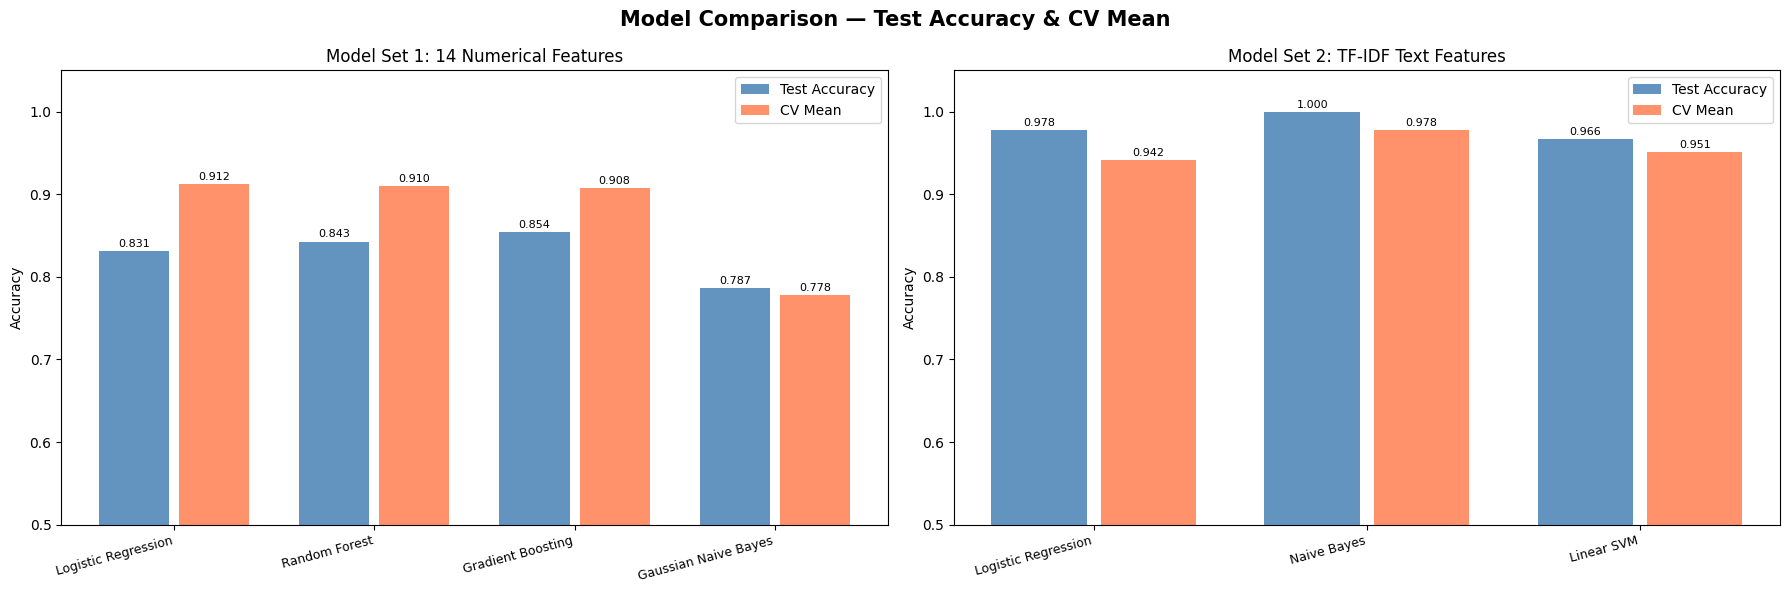

In [15]:
# CELL 13 — MODEL COMPARISON CHART
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Comparison — Test Accuracy & CV Mean', fontsize=15, fontweight='bold')

for ax, results, title in [
    (axes[0], num_results,   'Model Set 1: 14 Numerical Features'),
    (axes[1], tfidf_results, 'Model Set 2: TF-IDF Text Features')
]:
    names    = list(results.keys())
    accs     = [results[n]['accuracy'] for n in names]
    cv_means = [results[n]['cv_mean']  for n in names]
    x = np.arange(len(names))
    ax.bar(x - 0.2, accs,     0.35, label='Test Accuracy', color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, cv_means, 0.35, label='CV Mean',       color='coral',     alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    for i, (a, c) in enumerate(zip(accs, cv_means)):
        ax.text(i - 0.2, a + 0.005, f'{a:.3f}', ha='center', fontsize=8)
        ax.text(i + 0.2, c + 0.005, f'{c:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

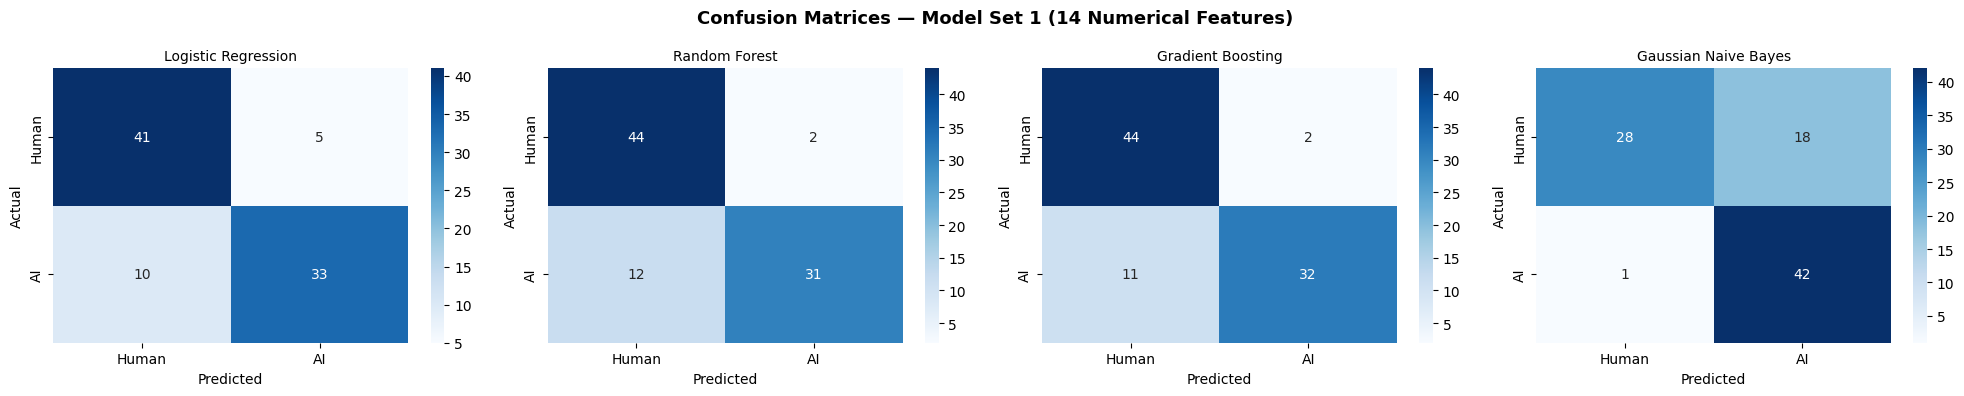

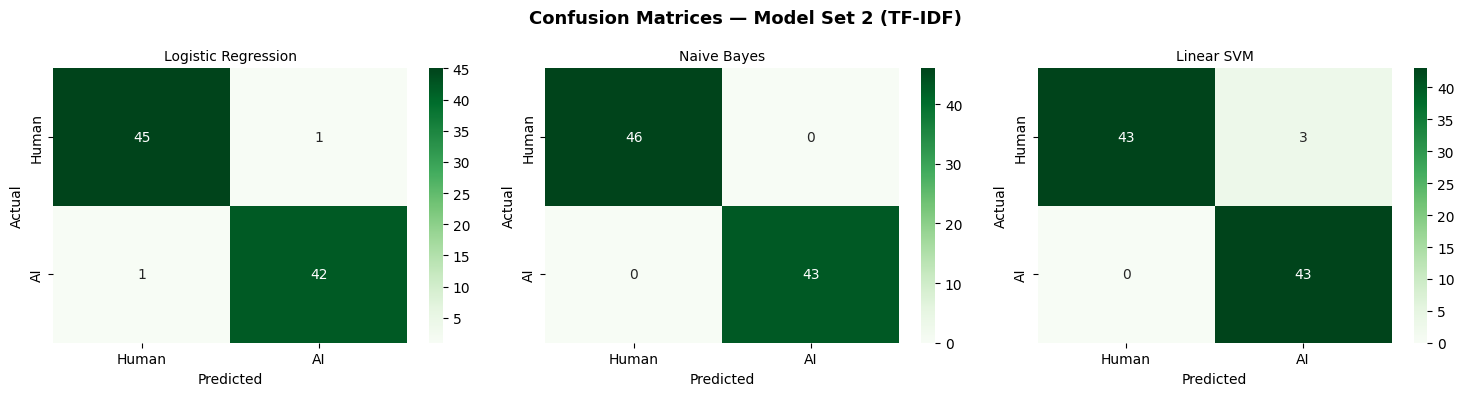

In [16]:
# CELL 14 — CONFUSION MATRICES
fig, axes = plt.subplots(1, len(num_models), figsize=(20, 4))
fig.suptitle('Confusion Matrices — Model Set 1 (14 Numerical Features)', fontsize=13, fontweight='bold')
for ax, (name, info) in zip(axes, num_results.items()):
    pred = info['model'].predict(X_test_n_sc)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(tfidf_models), figsize=(15, 4))
fig.suptitle('Confusion Matrices — Model Set 2 (TF-IDF)', fontsize=13, fontweight='bold')
for ax, (name, info) in zip(axes, tfidf_results.items()):
    pred = info['model'].predict(X_test_t)
    cm   = confusion_matrix(y_test_t, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

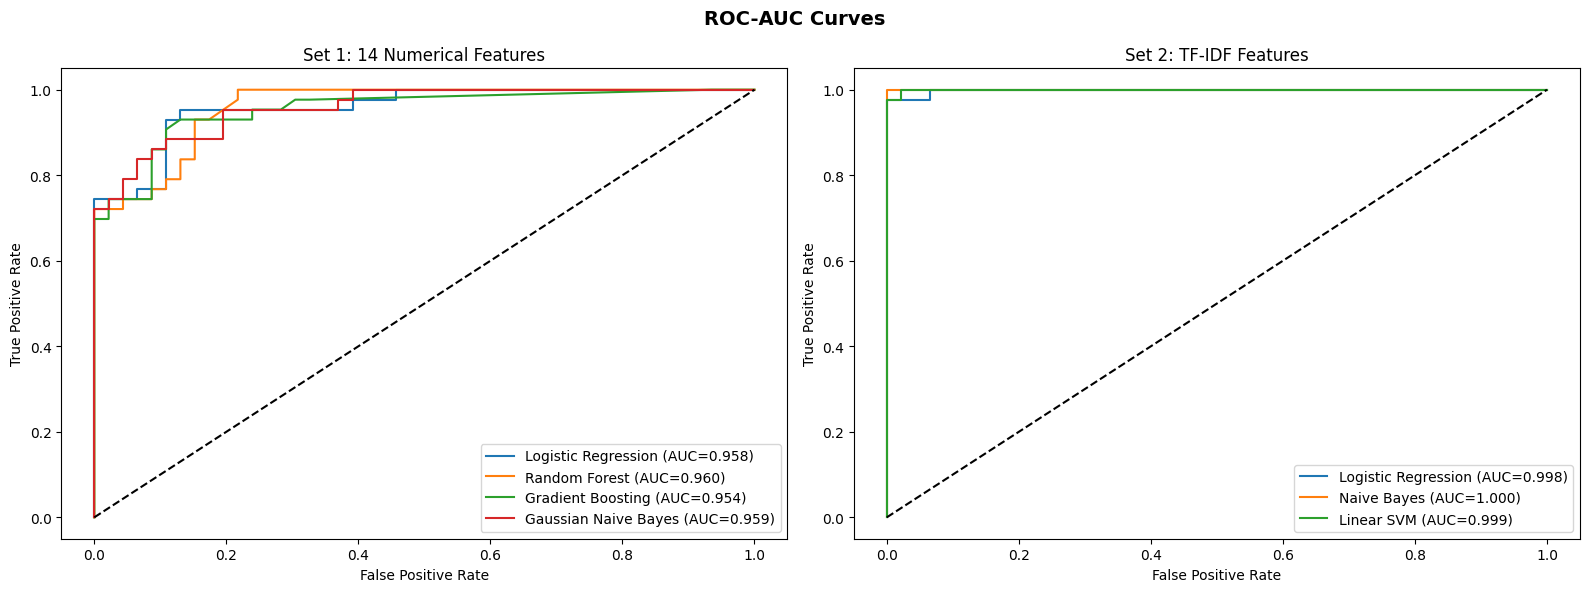

In [17]:
# CELL 15 — ROC-AUC CURVES
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC-AUC Curves', fontsize=14, fontweight='bold')

for name, info in num_results.items():
    model = info['model']
    scores = model.predict_proba(X_test_n_sc)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test_n_sc)
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_title('Set 1: 14 Numerical Features')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

for name, info in tfidf_results.items():
    model = info['model']
    scores = model.predict_proba(X_test_t)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test_t)
    fpr, tpr, _ = roc_curve(y_test_t, scores)
    auc = roc_auc_score(y_test_t, scores)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title('Set 2: TF-IDF Features')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

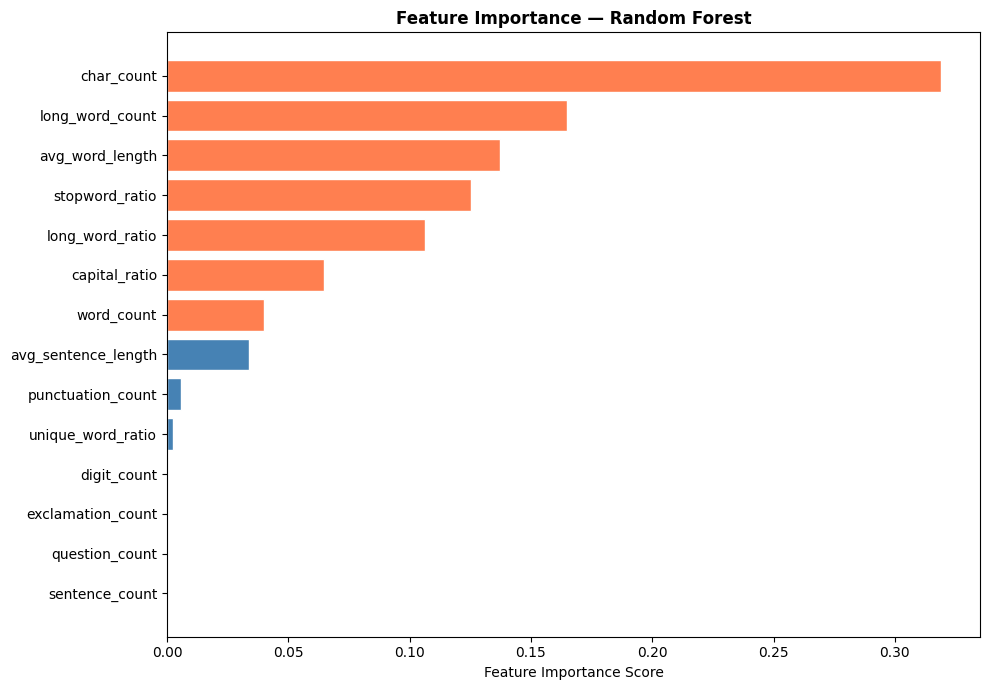


Top 5 Most Important Features:
        Feature  Importance
     char_count    0.319127
long_word_count    0.164773
avg_word_length    0.137077
 stopword_ratio    0.125184
long_word_ratio    0.106318


In [18]:
# CELL 16 — FEATURE IMPORTANCE (RANDOM FOREST)
rf_model = num_results['Random Forest']['model']
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['coral' if imp > fi_df['Importance'].median() else 'steelblue'
               for imp in fi_df['Importance']]
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors_bar, edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(fi_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

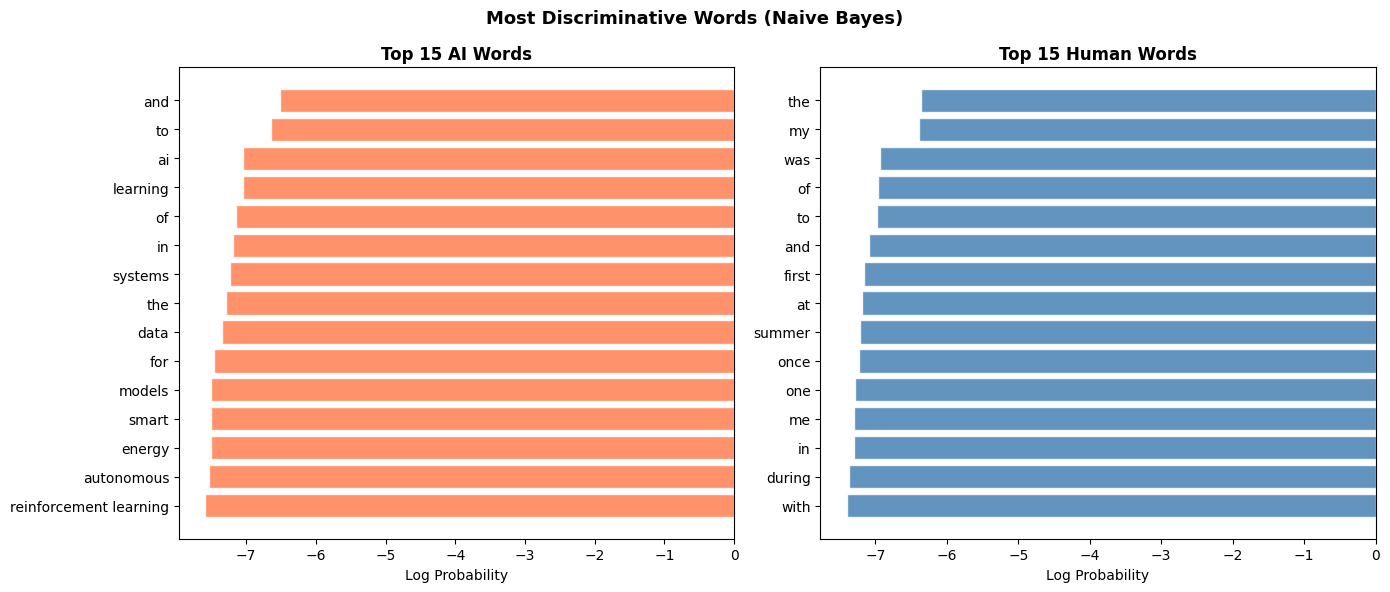

In [19]:
# CELL 17 — TOP AI vs HUMAN WORDS (NAIVE BAYES)
nb_model      = tfidf_results['Naive Bayes']['model']
feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, class_idx, title, color in [
    (axes[0], 1, 'Top 15 AI Words',    'coral'),
    (axes[1], 0, 'Top 15 Human Words', 'steelblue')
]:
    top_idx   = np.argsort(nb_model.feature_log_prob_[class_idx])[-15:]
    top_words = [feature_names[i] for i in top_idx]
    top_vals  = nb_model.feature_log_prob_[class_idx][top_idx]
    ax.barh(top_words, top_vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Log Probability')

plt.suptitle('Most Discriminative Words (Naive Bayes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# CELL 18 — PREDICTION FUNCTION
best_tfidf_model = tfidf_results['Logistic Regression']['model']

def extract_features_single(text):
    cleaned   = clean_text(text)
    words     = cleaned.split()
    sentences = [s for s in re.split(r'[.!?]+', text.strip()) if s.strip()]
    sc = max(1, len(sentences))
    wc = len(words) if words else 1
    return np.array([[
        len(text),
        wc,
        np.mean([len(w) for w in words]) if words else 0,
        len(set(words)) / wc,
        sc,
        wc / sc,
        len([w for w in words if w in STOP_WORDS]) / wc,
        sum(1 for c in text if c.isupper()) / len(text) if text else 0,
        sum(1 for c in text if c in string.punctuation),
        text.count('!'),
        text.count('?'),
        sum(c.isdigit() for c in text),
        sum(1 for w in words if len(w) > 6),
        sum(1 for w in words if len(w) > 6) / wc
    ]])

def predict_text(text):
    cleaned = clean_text(text)

    vec        = vectorizer.transform([cleaned])
    tfidf_pred = best_tfidf_model.predict(vec)[0]
    tfidf_conf = max(best_tfidf_model.predict_proba(vec)[0])

    feat_vec   = extract_features_single(text)
    feat_sc    = scaler.transform(feat_vec)
    rf_pred    = rf_model.predict(feat_sc)[0]
    rf_conf    = max(rf_model.predict_proba(feat_sc)[0])

    sentences = [s.strip() for s in text.split('.') if s.strip()]
    ai_count  = sum(1 for s in sentences
                    if best_tfidf_model.predict(vectorizer.transform([clean_text(s)]))[0] == 1)
    ai_pct = (ai_count / len(sentences) * 100) if sentences else 0

    print('=' * 55)
    print('  PREDICTION RESULT')
    print('=' * 55)
    print(f'  TF-IDF Model  : {"AI Generated" if tfidf_pred == 1 else "Human Written"}')
    print(f'    Confidence  : {tfidf_conf:.2%}')
    print(f'  Feature Model : {"AI Generated" if rf_pred == 1 else "Human Written"}')
    print(f'    Confidence  : {rf_conf:.2%}')
    print(f'  Sentence AI % : {ai_pct:.1f}%')
    final = 'AI Generated' if (tfidf_pred + rf_pred) >= 1 else 'Human Written'
    print(f'\n  Final Verdict : {final}')
    print('=' * 55)

user_text = input('Enter text to classify:\n> ')
predict_text(user_text)

Enter text to classify:
> Hey I like chocolates Do you want one ??
  PREDICTION RESULT
  TF-IDF Model  : Human Written
    Confidence  : 55.06%
  Feature Model : Human Written
    Confidence  : 89.00%
  Sentence AI % : 0.0%

  Final Verdict : Human Written


In [21]:
# CELL 19 — FINAL PROJECT SUMMARY
print('=' * 65)
print('  PROJECT SUMMARY — AI Text Detector')
print('=' * 65)
print(f'  Domain          : Natural Language Processing (NLP)')
print(f'  Learning Type   : Supervised Learning')
print(f'  Task            : Binary Classification (AI vs Human)')
print(f'  Dataset Size    : {df_clean.shape[0]} samples (after outlier removal)')
print(f'  Total Features  : {len(FEATURES)} numerical + TF-IDF (5000 text features)')
print()
print('  14 ENGINEERED FEATURES:')
for i, f in enumerate(FEATURES, 1):
    print(f'    {i:2d}. {f}')
print()
print('  MODEL SET 1 — 14 Numerical Features:')
best_num = max(num_results, key=lambda n: num_results[n]['accuracy'])
for name, r in num_results.items():
    tag = ' <- BEST' if name == best_num else ''
    print(f'    {name:30s}: Test={r["accuracy"]:.4f}, CV={r["cv_mean"]:.4f}+/-{r["cv_std"]:.4f}{tag}')
print()
print('  MODEL SET 2 — TF-IDF Text Features:')
best_tfidf = max(tfidf_results, key=lambda n: tfidf_results[n]['accuracy'])
for name, r in tfidf_results.items():
    tag = ' <- BEST' if name == best_tfidf else ''
    print(f'    {name:30s}: Test={r["accuracy"]:.4f}, CV={r["cv_mean"]:.4f}+/-{r["cv_std"]:.4f}{tag}')
print()
print('  STATISTICAL HIGHLIGHTS:')
print('    - Skewness & Kurtosis computed for all 14 features')
print('    - Symmetric features identified (|skew| < 0.5)')
print('    - Z-Score based outlier removal applied')
print('    - Two-sample Z-Test run on 6 key features')
print('    - Feature correlation heatmap computed')
print('    - Feature importance ranked via Random Forest')
print('=' * 65)

  PROJECT SUMMARY — AI Text Detector
  Domain          : Natural Language Processing (NLP)
  Learning Type   : Supervised Learning
  Task            : Binary Classification (AI vs Human)
  Dataset Size    : 445 samples (after outlier removal)
  Total Features  : 14 numerical + TF-IDF (5000 text features)

  14 ENGINEERED FEATURES:
     1. char_count
     2. word_count
     3. avg_word_length
     4. unique_word_ratio
     5. sentence_count
     6. avg_sentence_length
     7. stopword_ratio
     8. capital_ratio
     9. punctuation_count
    10. exclamation_count
    11. question_count
    12. digit_count
    13. long_word_count
    14. long_word_ratio

  MODEL SET 1 — 14 Numerical Features:
    Logistic Regression           : Test=0.8315, CV=0.9124+/-0.1305
    Random Forest                 : Test=0.8427, CV=0.9101+/-0.1247
    Gradient Boosting             : Test=0.8539, CV=0.9079+/-0.1184 <- BEST
    Gaussian Naive Bayes          : Test=0.7865, CV=0.7775+/-0.0805

  MODEL SET 2 — TF-